<a href="https://colab.research.google.com/github/vikash000x/vision_transformer-and-nanoVLM/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

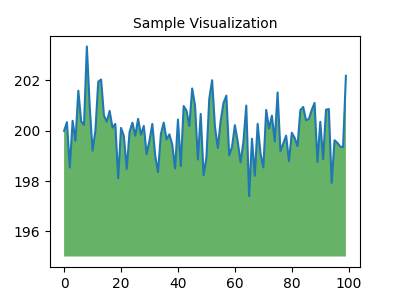

In [57]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

import library


In [58]:
import torch
import torchvision
import torch.utils.data as dataloader
import torch.nn as nn
import torchvision.transforms as transforms

data transformation for converting PIL to tensor format

In [59]:
data_transformation = transforms.Compose([transforms.ToTensor()])

download dataset (MNIST) - PIL

In [60]:
train_dataset = torchvision.datasets.MNIST(root="./data", train= True, download= True, transform = data_transformation)
val_dataset = torchvision.datasets.MNIST(root= "./data", train = False, download = True, transform = data_transformation)

variables that I need

In [61]:
img_size = 28
num_channels = 1
patch_size = 7
num_patches = (img_size // patch_size) ** 2
token_dim = 32
num_heads = 4
transformer_blocks = 4
num_classes = 10
mlp_hidden_dim = 64
learning_rate = 3e-4
epochs = 5


create batches for neural network training

In [62]:
train_loader = dataloader.DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = dataloader.DataLoader(val_dataset, batch_size = 64, shuffle = False)


patch embedding

In [63]:
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embed = nn.Conv2d(num_channels, token_dim, kernel_size=patch_size, stride= patch_size)


  def forward(self, x):
    x = self.patch_embed(x)
    x = x.flatten(2)
    x = x.transpose(1,2)
    return x

transformer encoder

In [64]:
from os import XATTR_SIZE_MAX
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layernorm1 = nn.LayerNorm(token_dim)
    self.layernorm2 = nn.LayerNorm(token_dim)
    self.multihead_attention = nn.MultiheadAttention(token_dim, num_heads, batch_first = True)
    self.mlp = nn.Sequential(
        nn.Linear(token_dim, mlp_hidden_dim),
        nn.GELU(),
        nn.Linear(mlp_hidden_dim, token_dim)
    )

  def forward(self, x):
    residual1 = x
    x = self.layernorm1(x)
    x = self.multihead_attention(x, x, x)[0]
    x = x + residual1

    residual2 = x
    x = self.layernorm2(x)
    x = self.mlp(x)
    x = x + residual2

    return x

MLP classification head

In [65]:
class MLPHead(nn.Module):
  def __init__(self):
    super().__init__()
    self.layernorm = nn.LayerNorm(token_dim)
    self.mlp = nn.Linear(token_dim, num_classes)

  def forward(self, x):
    x = self.layernorm(x)
    x = self.mlp(x)

    return x

combined

In [66]:
class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1, 1, token_dim))
    self.position_embedding = nn.Parameter(torch.randn(1, num_patches + 1, token_dim))
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder() for _ in range(transformer_blocks)])
    self.mlp_head = MLPHead()

  def forward(self, x):
    x = self.patch_embedding(x)
    B = x.shape[0]
    cls_token = self.cls_token.expand(B, -1, -1)
    x = torch.cat((cls_token, x), dim = 1)
    x = x + self.position_embedding

    x = self.transformer_blocks(x)
    x = x[:, 0]
    x = self.mlp_head(x)

    return x

device, model, optimizer and loss

In [67]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VisionTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = nn.CrossEntropyLoss()

train loop

In [68]:
for epoch in range(epochs):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0
  print(f"\n Epoch {epoch+1}")

  for batch_idx, (images, labels) in enumerate(train_loader):
     images, labels = images.to(device), labels.to(device)

     optimizer.zero_grad()
     outputs = model(images)
     loss = criterion(outputs, labels)
     loss.backward()
     optimizer.step()

     total_loss += loss.item()
     preds = outputs.argmax(dim = 1)
     correct = (preds == labels).sum().item()
     accuracy = 100 * correct / labels.size(0)

     correct_epoch += correct
     total_epoch += labels.size(0)

     if batch_idx % 100 == 0:
         print(f" Batch {batch_idx+1:3d}: Loss = {loss.item(): .4f}, Accuracy = {accuracy:.2f}%")

  epoch_acc = 100.0 * correct_epoch/total_epoch
  print(f"==> Epoch {epoch+1} summary: Total loss = {total_loss:.4f}, Accuracy = {epoch_acc:.2f}%")



 Epoch 1
 Batch   1: Loss =  2.3625, Accuracy = 9.38%
 Batch 101: Loss =  2.0860, Accuracy = 32.81%
 Batch 201: Loss =  1.0083, Accuracy = 76.56%
 Batch 301: Loss =  0.7262, Accuracy = 76.56%
 Batch 401: Loss =  0.5805, Accuracy = 82.81%
 Batch 501: Loss =  0.5537, Accuracy = 82.81%
 Batch 601: Loss =  0.5177, Accuracy = 87.50%
 Batch 701: Loss =  0.3110, Accuracy = 93.75%
 Batch 801: Loss =  0.2758, Accuracy = 95.31%
 Batch 901: Loss =  0.3440, Accuracy = 84.38%
==> Epoch 1 summary: Total loss = 727.0207, Accuracy = 76.63%

 Epoch 2
 Batch   1: Loss =  0.4075, Accuracy = 89.06%
 Batch 101: Loss =  0.3548, Accuracy = 92.19%
 Batch 201: Loss =  0.1829, Accuracy = 93.75%
 Batch 301: Loss =  0.1717, Accuracy = 95.31%
 Batch 401: Loss =  0.4051, Accuracy = 89.06%
 Batch 501: Loss =  0.2236, Accuracy = 93.75%
 Batch 601: Loss =  0.3042, Accuracy = 90.62%
 Batch 701: Loss =  0.3345, Accuracy = 92.19%
 Batch 801: Loss =  0.1818, Accuracy = 95.31%
 Batch 901: Loss =  0.3197, Accuracy = 93.75%

validation accuracy


In [70]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)

test_acc = 100 * correct/total
print(f"\n ==> val accuracy : {test_acc:.2f}%")


 ==> val accuracy : 96.50%


validation dataset

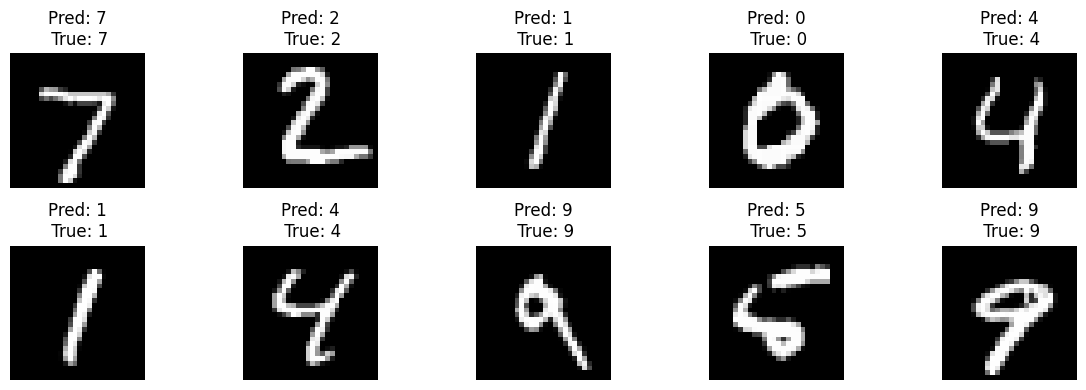

In [71]:
import matplotlib.pyplot as plt

#show 10 predictions from the first test batch
model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
  outputs = model(images)
  preds = outputs.argmax(dim=1)

images = images.cpu()
preds = preds.cpu()
labels = labels.cpu()

plt.figure(figsize = (12, 4))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(images[i].squeeze(), cmap="gray")
  plt.title(f"Pred: {preds[i].item()}\n True: {labels[i].item()}")
  plt.axis("off")
plt.tight_layout()
plt.show()
